In [ ]:
import io
import time

import pandas as pd
from IPython.display import Image
from ollama import chat
from pydantic import BaseModel

MODEL_NAME = "qwen3.5:35b"


def _extract_attr(obj: object, key: str, default: object = None) -> object:
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)


def run_vision_test(
    test_name: str,
    prompt: str,
    image_path: str,
    output_schema: type[BaseModel] | None = None,
    num_ctx: int | None = None,
) -> str | BaseModel:
    print(f"RUNNING TEST: {test_name}")
    print(f"Image: {image_path}")

    section_divider = "=" * 72
    block_divider = "-" * 72
    print(section_divider)

    request_kwargs: dict[str, object] = {}
    options = {}
    if output_schema is not None:
        request_kwargs["format"] = output_schema.model_json_schema()
    if num_ctx is not None:
        options["num_ctx"] = num_ctx

    start = time.perf_counter()
    stream = chat(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt, "images": [image_path]}],
        stream=True,
        **request_kwargs,
        options=options,
    )

    response_chunks: list[str] = []
    final_chunk = None
    thinking_started = False
    response_started = False

    for chunk in stream:
        final_chunk = chunk
        message = _extract_attr(chunk, "message", {})

        thinking = _extract_attr(message, "thinking", "")
        if isinstance(thinking, str) and thinking:
            if not thinking_started:
                print("THINKING")
                print(block_divider)
                thinking_started = True
            print(thinking, end="", flush=True)

        content = _extract_attr(message, "content", "")
        if isinstance(content, str) and content:
            if not response_started:
                if thinking_started:
                    print("\n")
                print("FINAL RESPONSE")
                print(block_divider)
                response_started = True

            print(content, end="", flush=True)
            response_chunks.append(content)

    full_response = "".join(response_chunks)
    elapsed_seconds = time.perf_counter() - start

    if thinking_started or response_started:
        print("\n")
    print(section_divider)
    print(f"Execution time: {elapsed_seconds:.2f}s")

    prompt_tokens = (
        _extract_attr(final_chunk, "prompt_eval_count") if final_chunk else None
    )
    completion_tokens = (
        _extract_attr(final_chunk, "eval_count") if final_chunk else None
    )

    if isinstance(prompt_tokens, int) and isinstance(completion_tokens, int):
        total_tokens = prompt_tokens + completion_tokens
        print("Token usage:")
        print(f"- Prompt tokens: {prompt_tokens}")
        print(f"- Completion tokens: {completion_tokens}")
        print(f"- Total tokens: {total_tokens}")
    else:
        print("Token usage: not available in stream metadata.")

    if output_schema is not None:
        return output_schema.model_validate_json(full_response)

    return full_response

## Recipe from Fridge


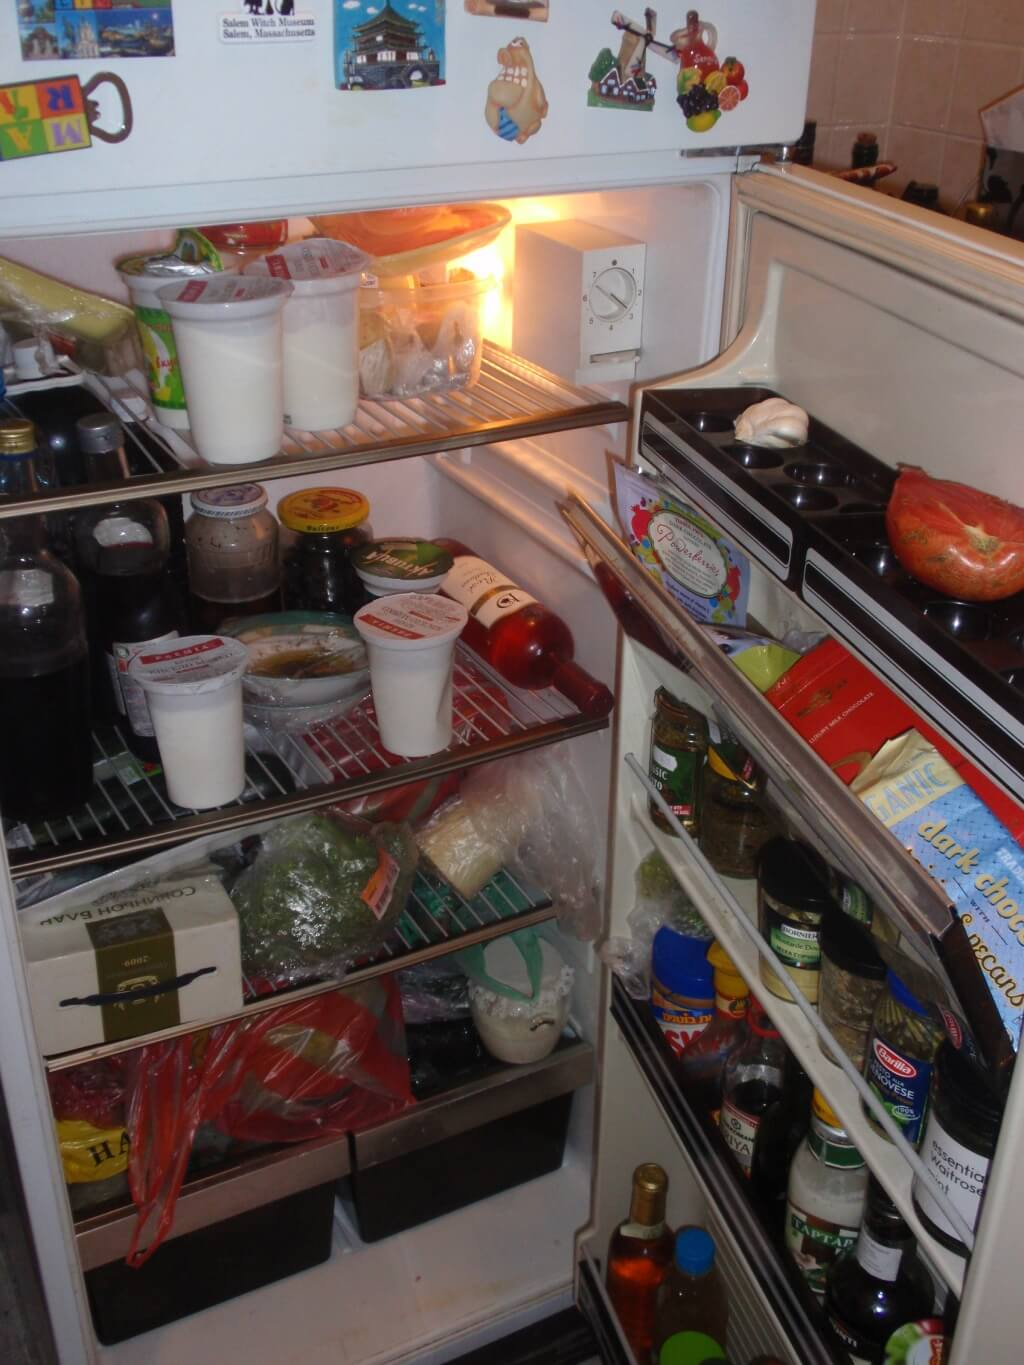

In [20]:
Image(filename="./images/bulgarian-fridge.jpg", width=512)

In [2]:
prompt_fridge = """
You are an expert chef. Look at the ingredients inside my fridge.
1. List the main ingredients you can clearly identify.
2. Give me a step-by-step recipe for a quick, delicious meal I can make right now using ONLY what is in this picture.
Keep it practical and easy.
"""

response = run_vision_test(
    test_name="The Empty Fridge Chef",
    prompt=prompt_fridge,
    image_path="./images/bulgarian-fridge.jpg",
)

RUNNING TEST: The Empty Fridge Chef
Image: ./images/bulgarian-fridge.jpg
THINKING
------------------------------------------------------------------------
The user wants me to act as an expert chef and analyze the contents of their fridge based on the provided image.

**Step 1: Inventory Analysis (Mental Scan & Identification)**
I need to look through the fridge shelf by shelf, left to right.

*   **Top Shelf:**
    *   Yogurt cups (white containers, likely plain or vanilla).
    *   Another yogurt cup (white container).
    *   Plastic tubs with what looks like rice or pasta salad or maybe just leftovers covered in plastic.
    *   A jar (looks like pesto or maybe a spread).
    *   A bottle of red wine (looks like a small 375ml or 500ml bottle, maybe a rosé or light red).
    *   A small container with dark liquid/sauce (maybe soy sauce or balsamic vinegar?).

*   **Middle Shelf:**
    *   Large dark bottle (looks like olive oil or vinegar, maybe soy sauce).
    *   A jar (looks like

## Image to Web Page


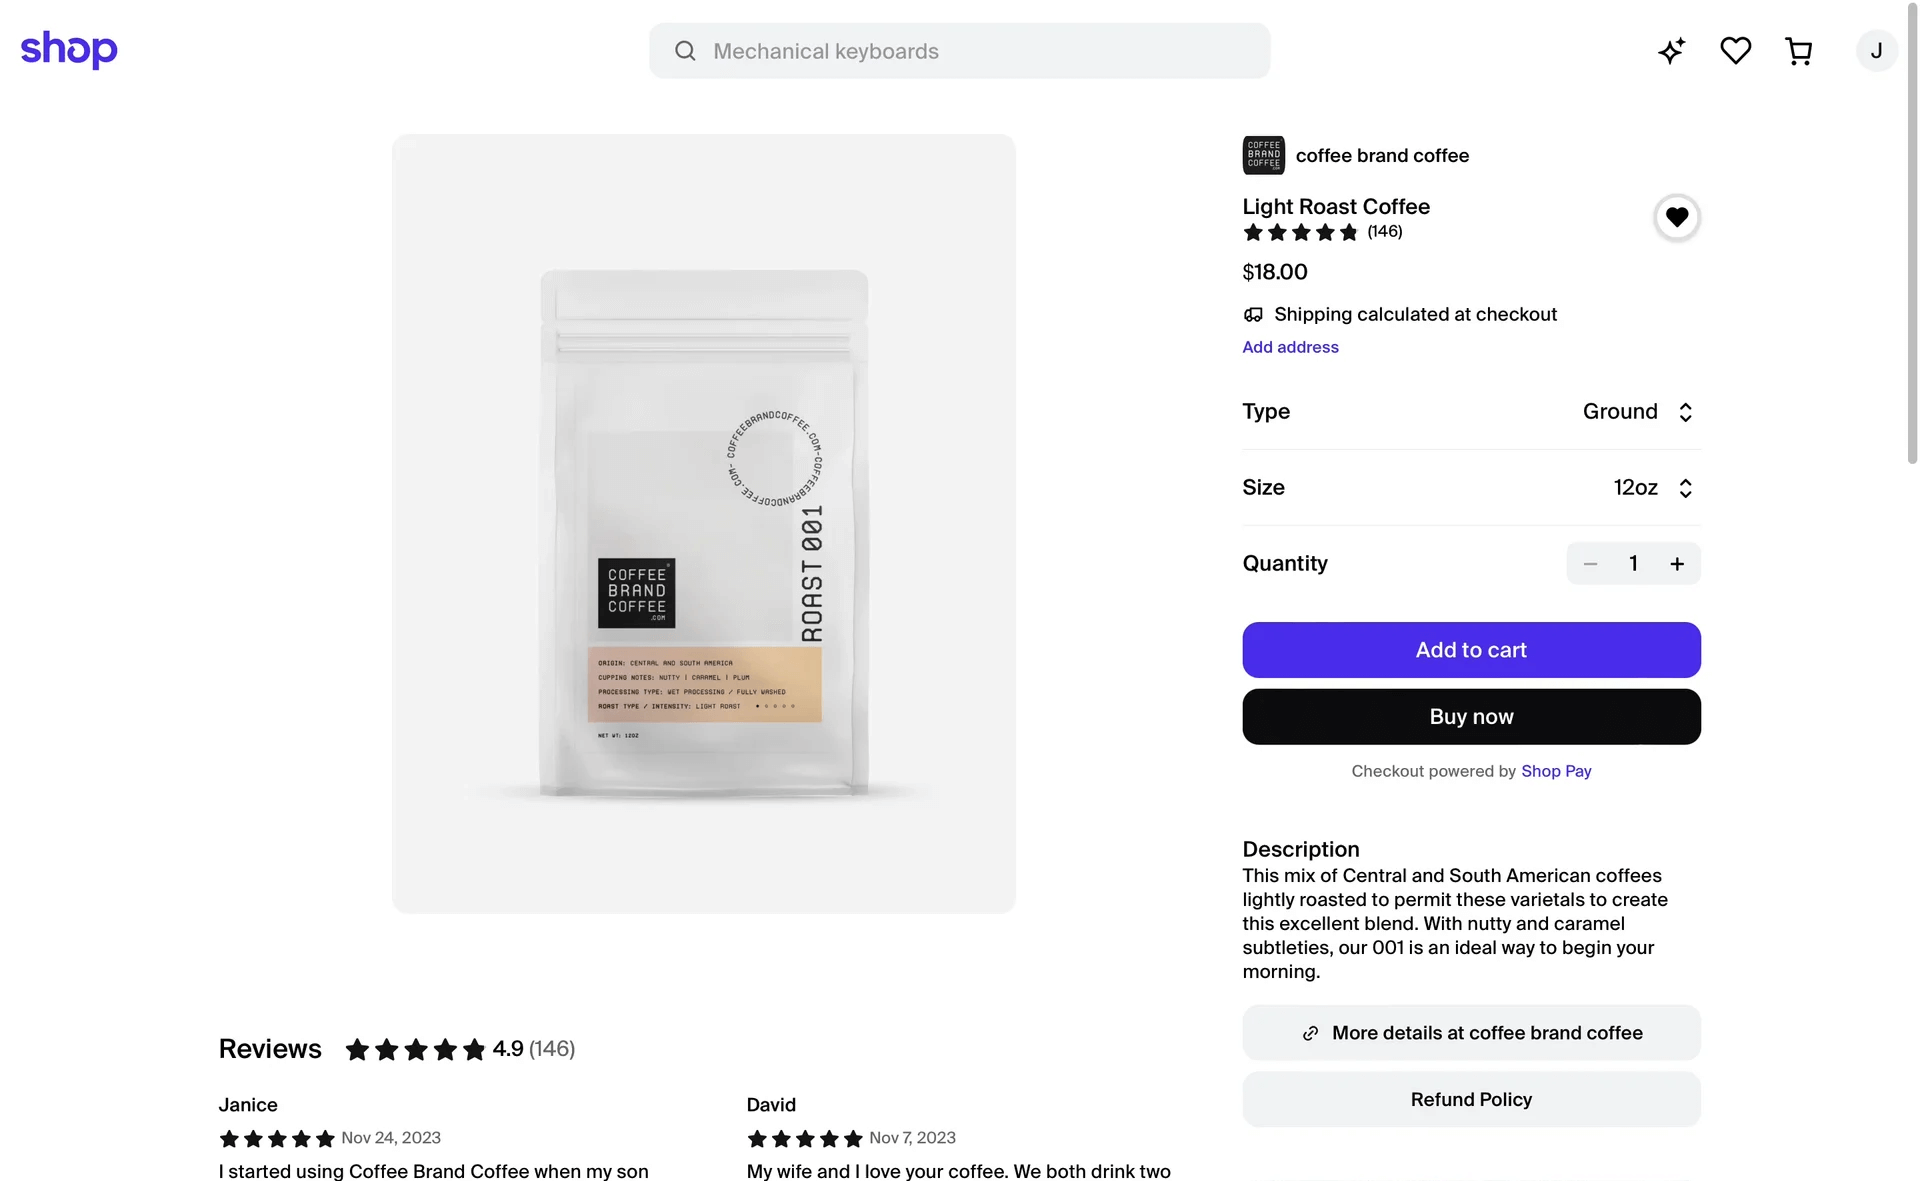

In [17]:
Image(filename="./images/web-shop.png", width=1024)

In [10]:
prompt_ui = """
You are an expert frontend developer. I am giving you a screenshot of a modern UI component.
Recreate this exact UI using HTML and Tailwind CSS. 
Output ONLY the raw HTML code inside a code block. Do not explain the code.
Ensure the layout, padding, and colors match as closely as possible.
"""

response = run_vision_test(
    test_name="Screenshot to Tailwind CSS",
    prompt=prompt_ui,
    image_path="./images/web-shop.png",
    num_ctx=64000,
)

RUNNING TEST: Screenshot to Tailwind CSS
Image: ./images/web-shop.png
THINKING
------------------------------------------------------------------------
The user wants me to recreate a specific UI component from a screenshot using HTML and Tailwind CSS.
The component is a product detail page, likely from an e-commerce site (specifically looks like a Shopify "Buy Button" or embedded checkout experience).

**Key Elements to Replicate:**
1.  **Header/Navbar:**
    *   Logo: "shop" (purple text).
    *   Search bar: "Mechanical keyboards" placeholder, grey background, search icon.
    *   Icons: Star, Heart, Cart, Profile (J).

2.  **Main Layout:**
    *   It's a two-column layout. Left side is the image, right side is the details.
    *   The left side actually seems to contain the image *and* the reviews section below it, or perhaps the image is top left and reviews are bottom left. Looking closely, the image is in a light grey box. Below that are the reviews.
    *   Wait, let's look at 

## Whiteboard Diagram Understanding


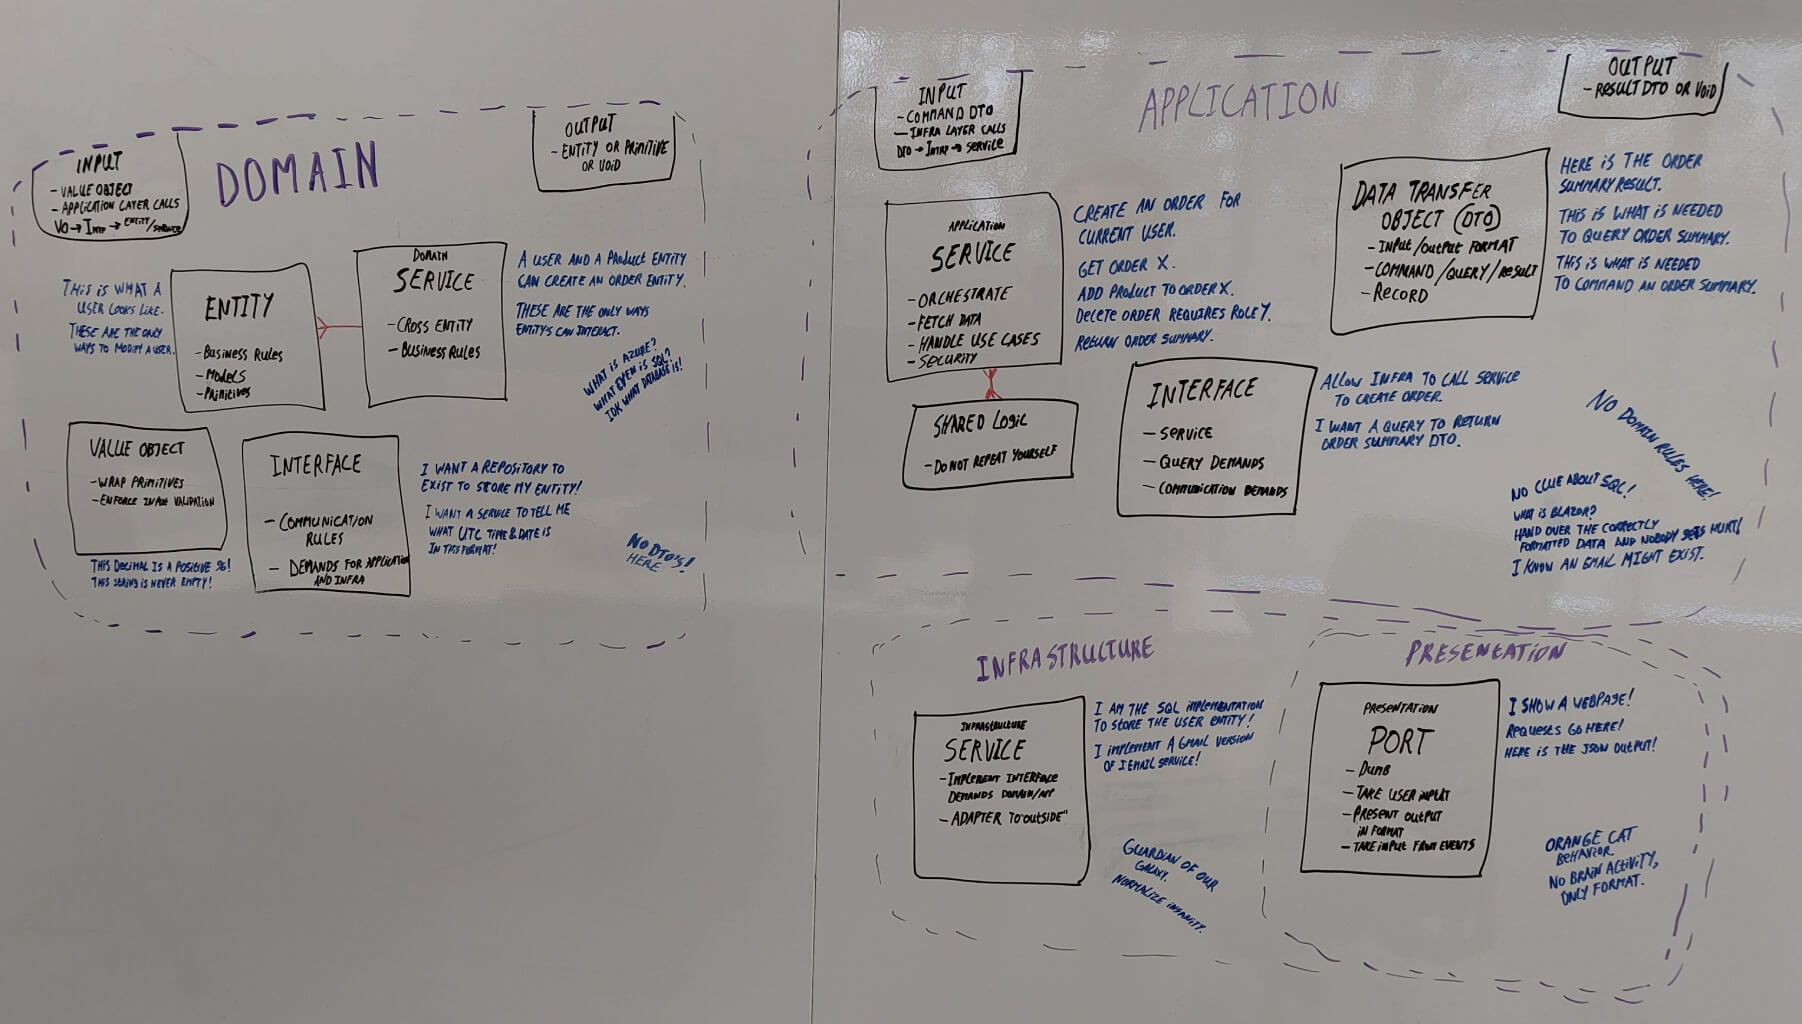

In [23]:
Image(filename="./images/whiteboard-diagram.jpg", width=1024)

In [11]:
response = prompt_architecture = """
I have drawn a system architecture diagram on this whiteboard.
1. Identify all the components in this diagram.
2. Explain the flow of data from the User to the final Output.
3. What kind of system is this? (e.g., Microservices, RAG, ETL pipeline?)
"""

response = run_vision_test(
    test_name="Whiteboard RAG to Documentation",
    prompt=prompt_architecture,
    image_path="./images/whiteboard-diagram.jpg",
)

RUNNING TEST: Whiteboard RAG to Documentation
Image: ./images/whiteboard-diagram.jpg
THINKING
------------------------------------------------------------------------
The user wants me to analyze a hand-drawn system architecture diagram.

**1. Identify Components:**
I need to scan the whiteboard and list every labeled box or section.
- **Top Left (Purple Dashed Box):** "DOMAIN"
    - Input: "Value Object", "Application Layer Calls", "VO -> Inter -> Entity/Service"
    - Output: "Entity or Primitive or Void"
    - Boxes inside: "Entity" (Business Rules, Models, Primitives), "Domain Service" (Cross Entity, Business Rules), "Value Object" (Wrap Primitives, Enforce Invariant Validation), "Interface" (Communication Rules, Demands for Application and Infra).
- **Top Right (Purple Dashed Box):** "APPLICATION"
    - Input: "Command DTO", "Infra layer calls", "DTO -> Inter -> Service"
    - Output: "Result DTO or Void"
    - Boxes inside: "Application Service" (Orchestrate, Fetch Data, Handle U

## Receipt Extraction


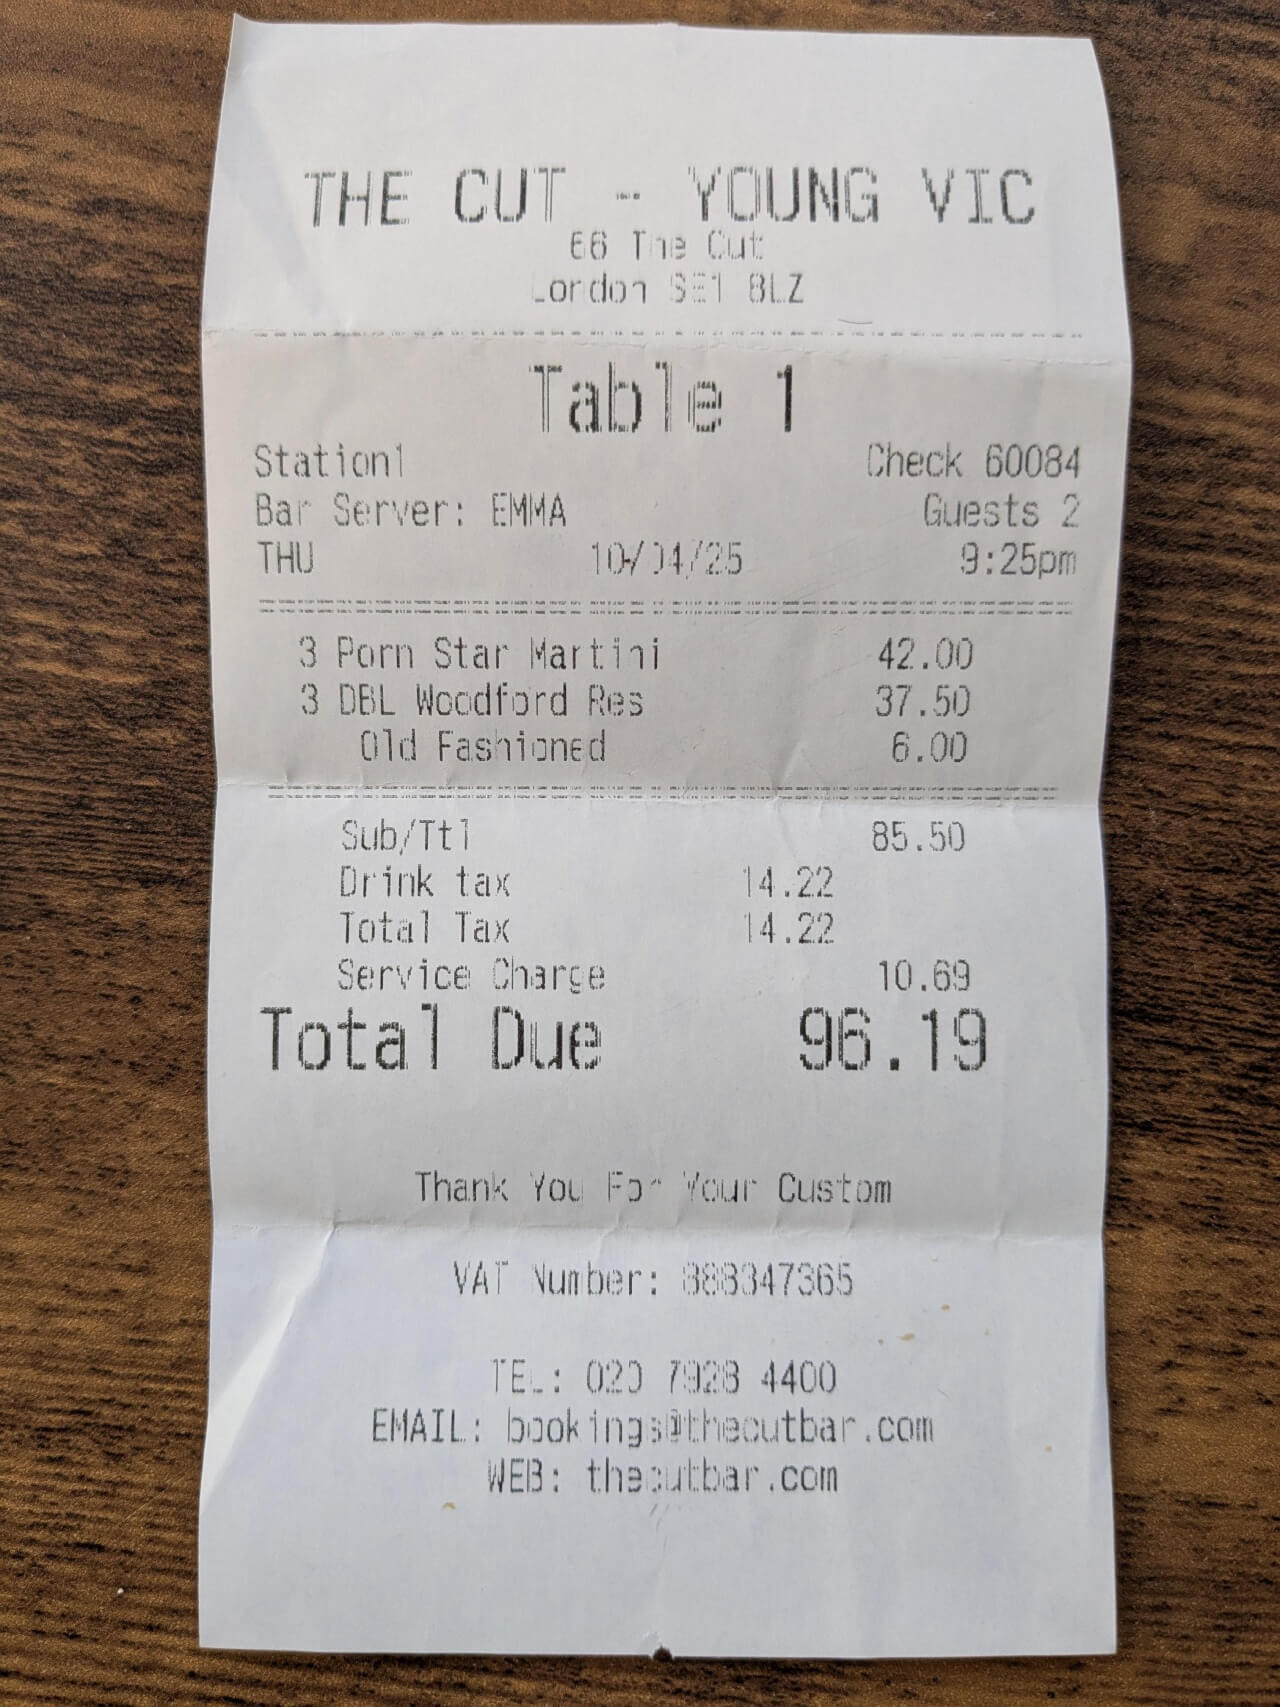

In [46]:
Image(filename="./images/receipt.jpg", width=1024)

In [45]:
prompt_invoice = """
Extract the data from this scanned receipt. 
Return the data STRICTLY as a JSON object with the following keys:
- "vendor_name" (string)
- "total_amount" (float)
- "date" (string, format YYYY-MM-DD)
- "items" (list of objects with "description" and "price")

Do not include any markdown formatting or conversational text. Just the JSON.
"""

response = run_vision_test(
    test_name="Crumpled Receipt to JSON",
    prompt=prompt_invoice,
    image_path="./images/receipt.jpg",
)

RUNNING TEST: Crumpled Receipt to JSON
Image: ./images/receipt.jpg
THINKING
------------------------------------------------------------------------
Based on the visual content of the receipt, I will extract the requested fields.

1.  **Vendor Name**: The top of the receipt clearly states "THE CUT - YOUNG VIC".
2.  **Total Amount**: Near the bottom, there is a large bold text "Total Due" with the value "96.19".
3.  **Date**: Looking at the middle section, under "THU", I see "10/04/25". This corresponds to YYYY-MM-DD format as 2025-04-10 or potentially 2025-10-04 depending on interpretation, but usually UK dates are DD/MM/YY. Let's look closer. "10/04/25". Wait, let's re-examine. It looks like "10/04/25". Given the location is London ("London SE1 8LZ"), the date format is likely DD/MM/YY. So 10th April 2025. Wait, let me look really closely at the image. It actually looks like "10/04/25". Let's assume standard UK format DD/MM/YY. So 2025-04-10. Wait, looking at the spacing, it could be 

## Chart Data Extraction


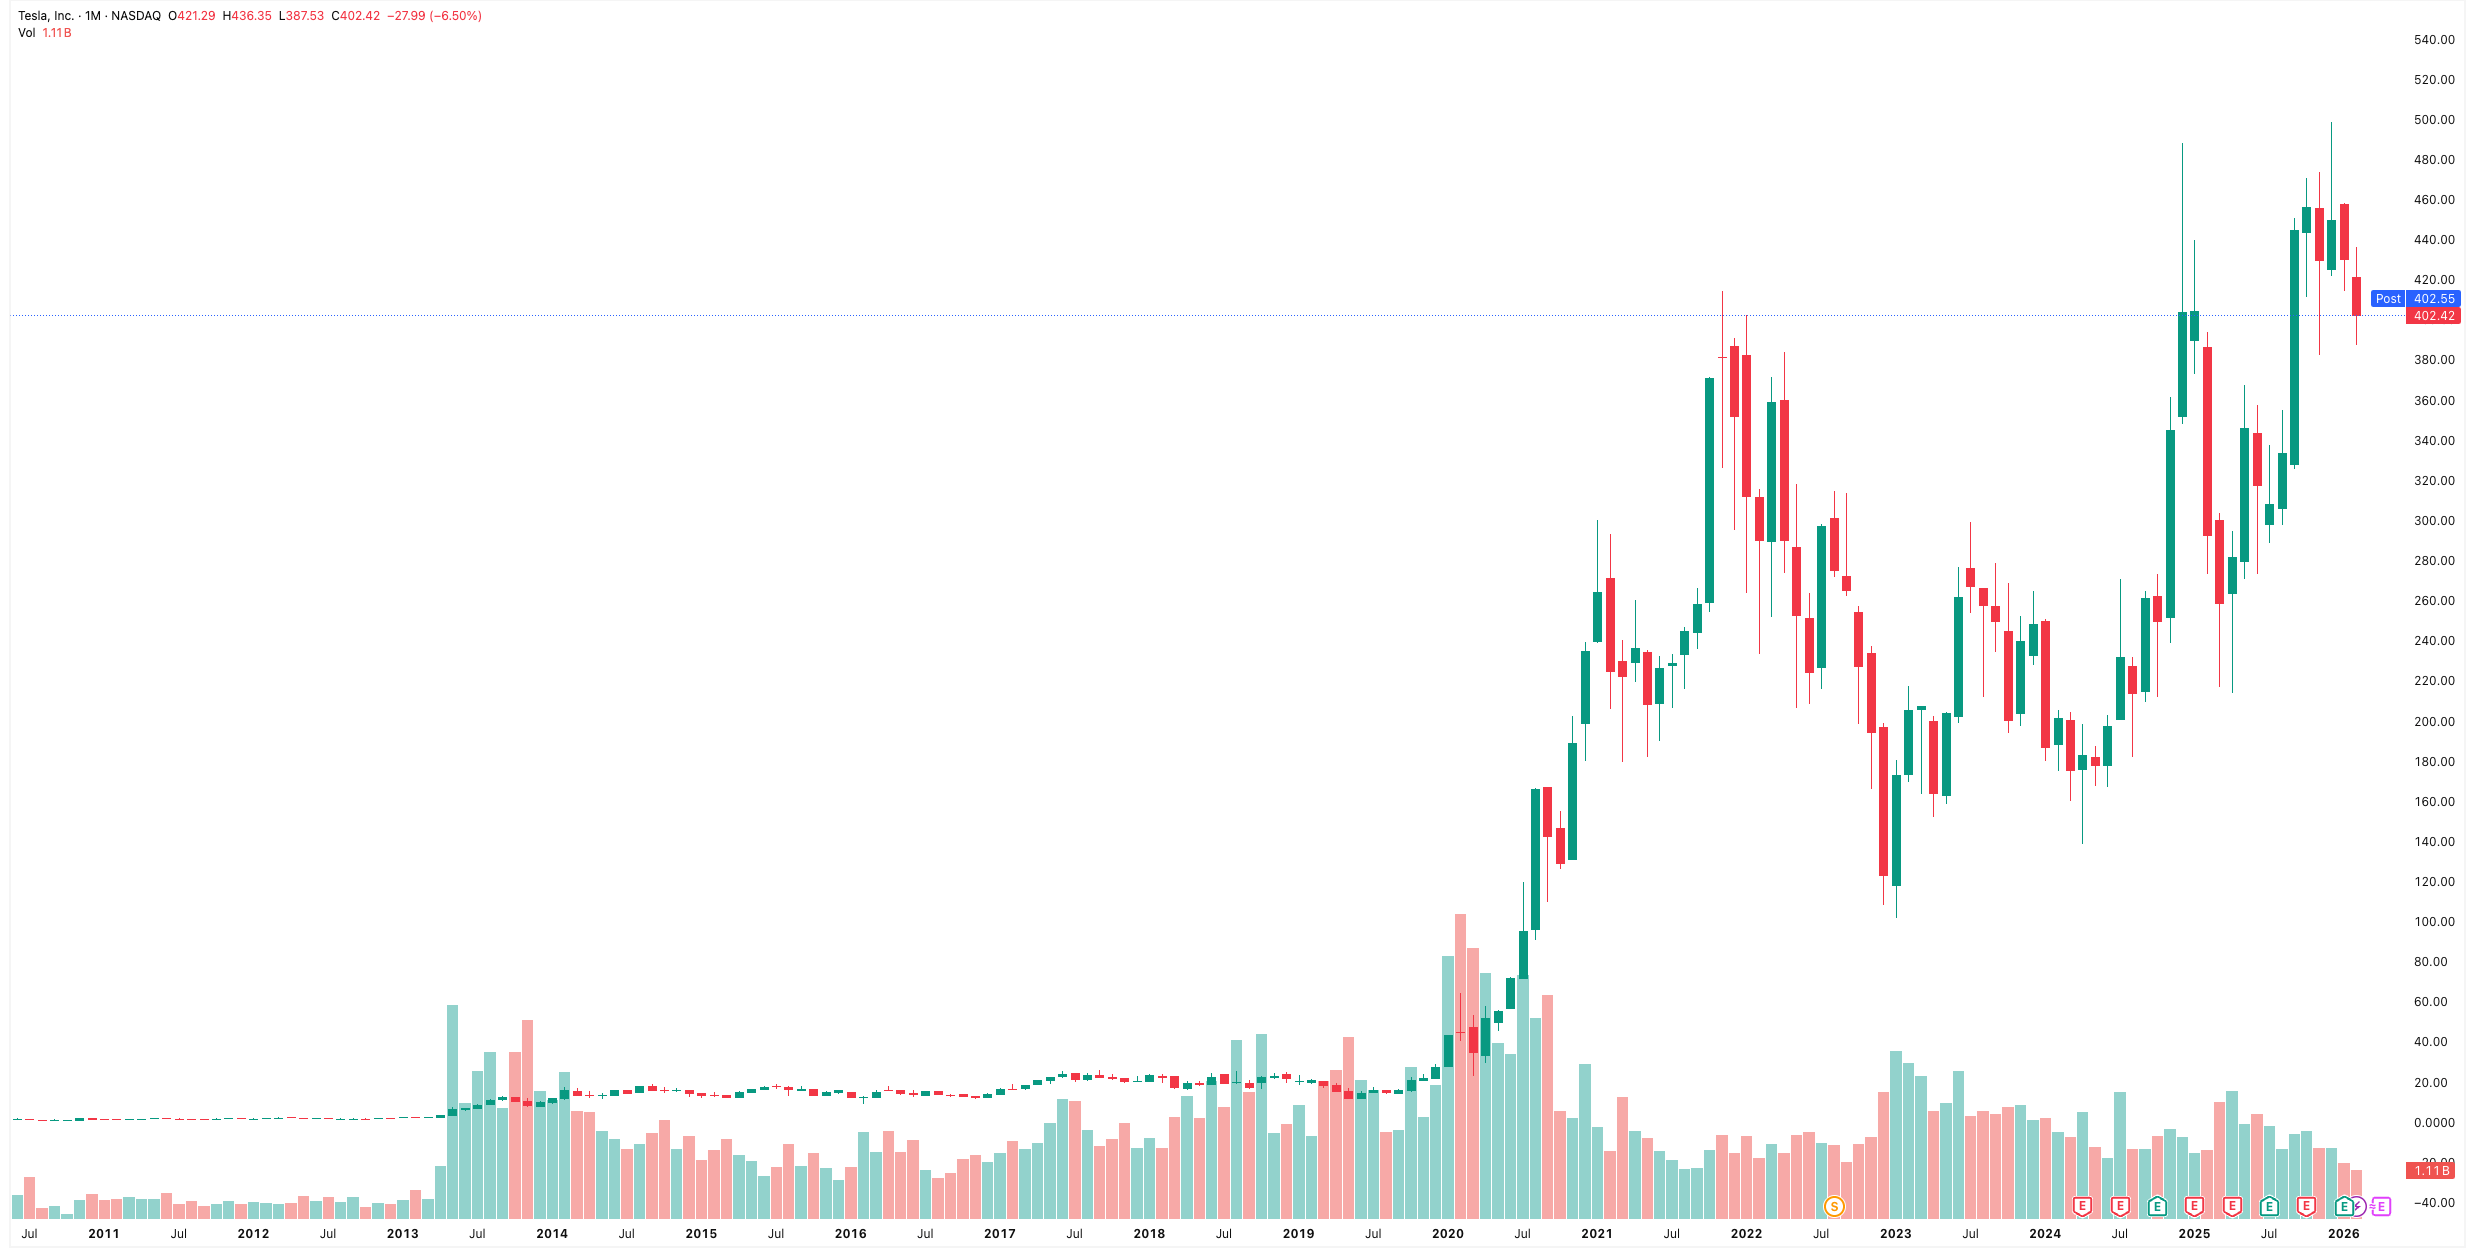

In [47]:
Image(filename="./images/chart-price.png", width=1280)

In [13]:
response = prompt_chart = """
You are an expert data analyst. I have an image of a business chart, but I have lost the original Excel file.
1. Carefully read the X-axis and Y-axis.
2. Estimate the exact value for each data point shown in the chart.
3. Output this data STRICTLY as a raw CSV (Comma Separated Values) format so I can immediately import it into Pandas.
Include the headers as the first row.
"""

response = run_vision_test(
    test_name="The Lost Data Chart Extractor",
    prompt=prompt_chart,
    image_path="./images/chart-price.png",
    num_ctx=64000,
)

RUNNING TEST: The Lost Data Chart Extractor
Image: ./images/chart-price.png
THINKING
------------------------------------------------------------------------
The user wants me to extract data from a candlestick chart.
1.  **Analyze the Chart:**
    *   **Type:** Candlestick chart with volume bars at the bottom.
    *   **X-axis:** Time. It spans from roughly 2010 to 2026 (labeled). The intervals are roughly yearly.
    *   **Y-axis (Price):** Ranges from roughly -40 to 540.
    *   **Y-axis (Volume):** Ranges from 0 to 540 (scaled similarly to price, likely just for visual alignment, though volume is usually separate). Wait, the bottom scale is labeled 0.0000 to 540.00, but there's also a scale at the very bottom right labeled -40.00. This looks like a dual-axis chart or just a very specific scaling. Let's look closer. The volume bars are at the bottom. The price candles are in the main area.
    *   **Data Points:** These are monthly candlesticks (labeled "1M" in the top left).
    * 

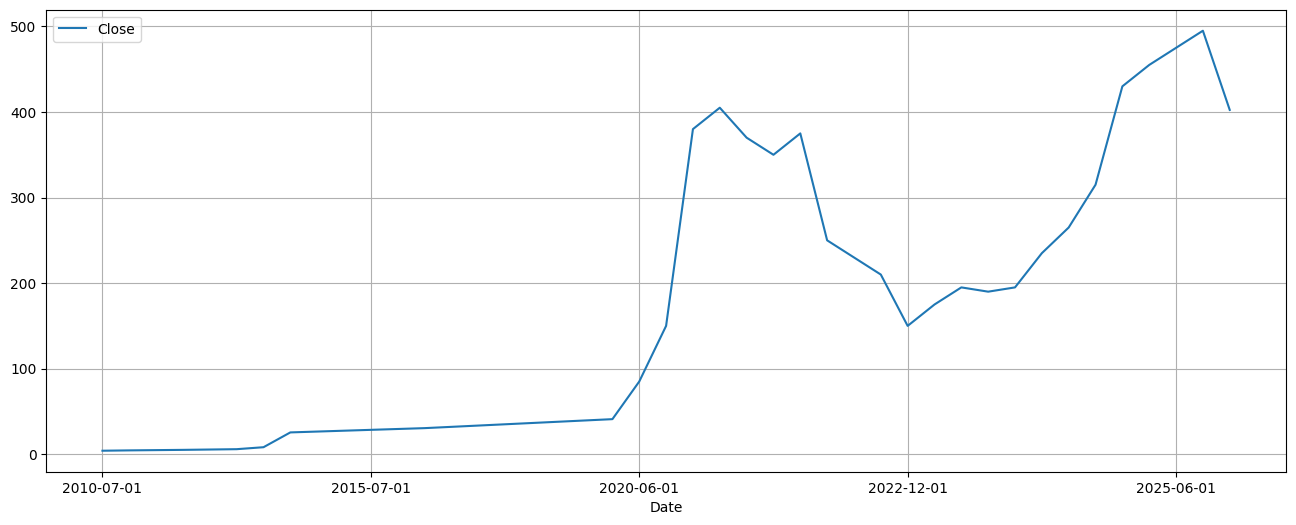

In [44]:
chart_data = """
Date,Open,High,Low,Close,Volume
2010-07-01,3.50,5.20,3.00,4.10,5000000
2011-01-01,4.20,4.80,3.90,4.50,6000000
2011-07-01,4.60,5.10,4.40,4.80,5500000
2012-01-01,4.90,5.40,4.60,5.10,6000000
2012-07-01,5.30,5.80,5.00,5.50,6500000
2013-01-01,5.60,6.20,5.30,5.90,7000000
2013-07-01,6.00,8.50,5.80,8.20,15000000
2014-01-01,24.50,26.00,23.00,25.50,20000000
2014-07-01,26.00,27.50,25.00,26.50,22000000
2015-01-01,27.00,28.50,26.00,27.50,21000000
2015-07-01,28.00,29.00,27.00,28.50,20000000
2016-01-01,29.00,30.50,28.00,29.50,22000000
2016-07-01,30.00,31.50,29.00,30.50,23000000
2017-01-01,31.00,33.00,30.00,32.00,25000000
2017-07-01,32.50,34.50,31.50,33.50,28000000
2018-01-01,34.00,36.00,33.00,35.00,30000000
2018-07-01,35.50,37.50,34.50,36.50,32000000
2019-01-01,37.00,39.00,36.00,38.00,35000000
2019-07-01,38.50,40.50,37.50,39.50,38000000
2020-01-01,40.00,42.00,39.00,41.00,40000000
2020-06-01,45.00,90.00,42.00,85.00,150000000
2020-09-01,140.00,155.00,135.00,150.00,200000000
2020-12-01,320.00,390.00,310.00,380.00,250000000
2021-03-01,390.00,410.00,380.00,405.00,220000000
2021-06-01,385.00,395.00,360.00,370.00,200000000
2021-09-01,360.00,370.00,340.00,350.00,190000000
2021-12-01,380.00,390.00,360.00,375.00,210000000
2022-03-01,260.00,280.00,240.00,250.00,300000000
2022-06-01,240.00,260.00,220.00,230.00,280000000
2022-09-01,220.00,230.00,200.00,210.00,270000000
2022-12-01,180.00,200.00,120.00,150.00,350000000
2023-03-01,160.00,180.00,150.00,175.00,250000000
2023-06-01,180.00,200.00,170.00,195.00,260000000
2023-09-01,200.00,210.00,180.00,190.00,250000000
2023-12-01,200.00,210.00,180.00,195.00,270000000
2024-03-01,220.00,240.00,210.00,235.00,280000000
2024-06-01,250.00,270.00,240.00,265.00,300000000
2024-09-01,300.00,320.00,290.00,315.00,320000000
2024-12-01,380.00,440.00,360.00,430.00,450000000
2025-03-01,440.00,460.00,420.00,455.00,400000000
2025-06-01,460.00,480.00,450.00,475.00,420000000
2025-09-01,480.00,500.00,470.00,495.00,450000000
2025-12-01,421.29,436.35,387.53,402.42,1110000000
"""

file_like_object = io.StringIO(chart_data)
df = pd.read_csv(file_like_object, index_col="Date")
df.plot(y="Close", figsize=(16, 6), grid=True, x_compat=True);

## References

- [My dad bought a Corecom Fridge in 1982 and we’re never changing it](https://zikata.wordpress.com/2010/07/25/my-dad-bought-a-corecom-fridge-in-1982-and-we%E2%80%99re-never-changing-it/)
- [Did i do any good? Trying to graph and understand DDD using Clean Architecture book as source.](https://www.reddit.com/r/softwarearchitecture/comments/1q0buq1/did_i_do_any_good_trying_to_graph_and_understand/)
